In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DATA_DIR = Path("../data")
EXTERNAL_DIR = DATA_DIR / "external"
PROCESSED_DIR = DATA_DIR / "processed"

TABLE_DIR = Path("../outputs/tables")
FIGURE_DIR = Path("../outputs/figures")

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries imported and output folders created.")

Libraries imported and output folders created.


In [2]:
pip install odfpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
region_file = (
    EXTERNAL_DIR
    / "evci0101_2026-04_EV_chargers_by_region_and_country_UK.ods"
)

local_file = (
    EXTERNAL_DIR
    / "evci0102_2026-04_EV_chargers_by_local_authority_and_county_UK.ods"
)

power_file = (
    EXTERNAL_DIR
    / "evci0201_2026-04_EV_chargers_by_power_band_UK.ods"
)

required_files = [
    region_file,
    local_file,
    power_file
]

missing_files = [
    str(file)
    for file in required_files
    if not file.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing EV files:\n- "
        + "\n- ".join(missing_files)
    )

ev_region_book = pd.ExcelFile(
    region_file,
    engine="odf"
)

ev_local_book = pd.ExcelFile(
    local_file,
    engine="odf"
)

ev_power_book = pd.ExcelFile(
    power_file,
    engine="odf"
)

print("Region sheets:", ev_region_book.sheet_names)
print("Local authority sheets:", ev_local_book.sheet_names)
print("Power-band sheets:", ev_power_book.sheet_names)

Region sheets: ['Cover', 'Contents', 'Notes', 'EVCI0101a', 'EVCI0101b', 'EVCI0101c', 'EVCI0101d', 'EVCI0101e']
Local authority sheets: ['Cover', 'Contents', 'Notes', 'EVCI0102a', 'EVCI0102b', 'EVCI0102c', 'EVCI0102d', 'EVCI0102e']
Power-band sheets: ['Cover', 'Contents', 'Notes', 'EVCI0201a', 'EVCI0201b']


In [4]:
ev_region_preview = pd.read_excel(
    region_file,
    sheet_name="EVCI0101a",
    engine="odf",
    header=None
)

ev_power_preview = pd.read_excel(
    power_file,
    sheet_name="EVCI0201a",
    engine="odf",
    header=None
)

print("Regional dataset shape:", ev_region_preview.shape)
display(ev_region_preview.head(12))

print("Power-band dataset shape:", ev_power_preview.shape)
display(ev_power_preview.head(15))

Regional dataset shape: (9, 17)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,EVCI0101a: Public electric vehicle chargers by...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,This worksheet contains one table. Some cells ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Date,Notes,United Kingdom,Great Britain,England,North East,North West,Yorkshire and The Humber,East Midlands,West Midlands,East of England,London,South East,South West,Wales,Scotland,Northern Ireland
3,2025-01-01 00:00:00,[note 4],102771,101738,86085,3504,7271,5720,5505,8689,8249,25474,13726,7947,4754,10899,1033
4,2025-04-01 00:00:00,[note 4],105771,104735,88174,3438,7395,5783,5389,9083,8552,26505,13838,8191,4936,11625,1036
5,2025-07-01 00:00:00,[note 4],110132,109079,91772,3552,7804,6202,5277,9732,8898,27406,14471,8430,5237,12070,1053
6,2025-10-01 00:00:00,[note 4],114486,113355,95496,3560,8142,6349,5405,9723,9103,29522,14869,8823,5610,12249,1131
7,2026-01-01 00:00:00,[no note],116052,114944,97235,3834,8120,6153,6119,9890,9269,30728,14406,8716,5644,12065,1108
8,2026-04-01 00:00:00,[no note],119080,117935,99551,3986,8376,6254,6263,10059,9887,30909,14750,9067,5712,12672,1145


Power-band dataset shape: (5, 6)


,0,1,2,3,4,5
0,EVCI0201a: Public electric vehicle chargers by...,NaN,NaN,NaN,NaN,NaN
1,This worksheet contains one table. Some cells ...,NaN,NaN,NaN,NaN,NaN
2,Date,Notes,Standard,Standard plus,Rapid,Ultra-rapid
3,2026-01-01 00:00:00,[no note],57807,31867,14451,11927
4,2026-04-01 00:00:00,[note 3],60039,31669,14451,12921


In [5]:
ev_infrastructure_summary = pd.DataFrame({
    "Charger_Category": [
        "Standard",
        "Standard Plus",
        "Rapid",
        "Ultra-Rapid"
    ],
    "Number_of_Chargers": [
        60039,
        31669,
        14451,
        12921
    ]
})

ev_infrastructure_summary["Share_Percent"] = (
    ev_infrastructure_summary["Number_of_Chargers"]
    / ev_infrastructure_summary["Number_of_Chargers"].sum()
    * 100
)

display(ev_infrastructure_summary)

,Charger_Category,Number_of_Chargers,Share_Percent
0,Standard,60039,50.419046
1,Standard Plus,31669,26.594726
2,Rapid,14451,12.135539
3,Ultra-Rapid,12921,10.850689


In [6]:
ev_infrastructure_summary.to_csv(
    TABLE_DIR / "ev_infrastructure_summary.csv",
    index=False
)

print(
    "Saved:",
    TABLE_DIR / "ev_infrastructure_summary.csv"
)

Saved: ..\outputs\tables\ev_infrastructure_summary.csv


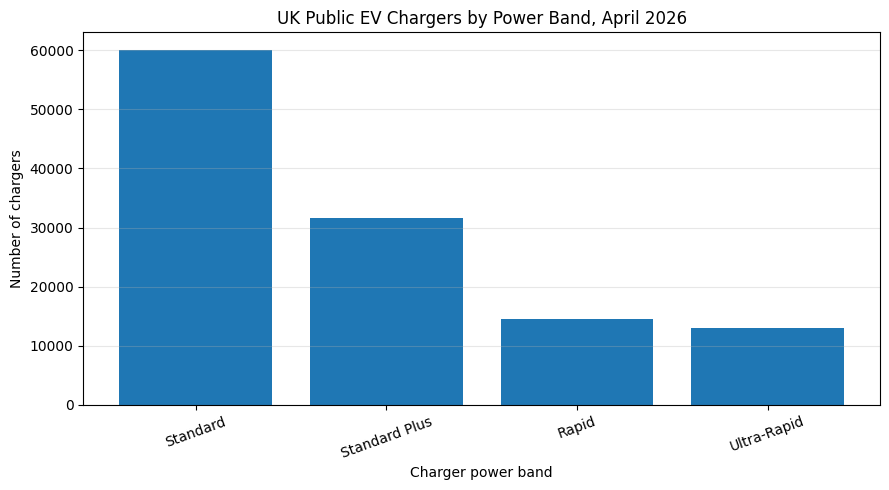

In [7]:
plt.figure(figsize=(9, 5))

plt.bar(
    ev_infrastructure_summary["Charger_Category"],
    ev_infrastructure_summary["Number_of_Chargers"]
)

plt.title(
    "UK Public EV Chargers by Power Band, April 2026"
)
plt.xlabel("Charger power band")
plt.ylabel("Number of chargers")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "ev_chargers_by_power_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
ev_context_summary = pd.DataFrame({
    "Metric": [
        "UK chargers, January 2025",
        "UK chargers, July 2025",
        "London chargers, July 2025",
        "Standard and Standard Plus share"
    ],
    "Value": [
        102771,
        110132,
        27406,
        "77%"
    ]
})

display(ev_context_summary)

,Metric,Value
0,"UK chargers, January 2025",102771
1,"UK chargers, July 2025",110132
2,"London chargers, July 2025",27406
3,Standard and Standard Plus share,77%


In [9]:
ev_context_summary.to_csv(
    TABLE_DIR / "ev_context_summary.csv",
    index=False
)

print(
    "Saved:",
    TABLE_DIR / "ev_context_summary.csv"
)

Saved: ..\outputs\tables\ev_context_summary.csv


In [10]:
candidate_files = [
    TABLE_DIR / "stress_labelled_data.csv",
    PROCESSED_DIR / "stress_labelled_data.csv",
    PROCESSED_DIR / "model_ready_data.csv",
    PROCESSED_DIR / "neighbourhood_demand.csv"
]

demand_file = next(
    (
        file
        for file in candidate_files
        if file.exists()
    ),
    None
)

if demand_file is None:
    raise FileNotFoundError(
        "No suitable demand dataset was found.\n"
        "Checked:\n- "
        + "\n- ".join(
            str(file)
            for file in candidate_files
        )
    )

neighbourhood = pd.read_csv(demand_file)

required_columns = {
    "datetime",
    "total_demand_kwh"
}

missing_columns = (
    required_columns
    .difference(neighbourhood.columns)
)

if missing_columns:
    raise ValueError(
        "The demand dataset is missing: "
        f"{sorted(missing_columns)}"
    )

neighbourhood["datetime"] = pd.to_datetime(
    neighbourhood["datetime"],
    errors="coerce"
)

neighbourhood["total_demand_kwh"] = pd.to_numeric(
    neighbourhood["total_demand_kwh"],
    errors="coerce"
)

neighbourhood = (
    neighbourhood
    .dropna(
        subset=[
            "datetime",
            "total_demand_kwh"
        ]
    )
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Loaded demand file:", demand_file)
print("Dataset shape:", neighbourhood.shape)

display(neighbourhood.head())

Loaded demand file: ..\data\processed\model_ready_data.csv
Dataset shape: (20209, 13)


,datetime,total_demand_kwh,hour,day,month,weekday,is_weekend,season,lag_1,lag_48,lag_96,rolling_mean_48,rolling_std_48
0,2013-01-03 00:00:00,209.864,0,3,1,3,0,0,243.522,198.338,220.013,240.736854,91.920733
1,2013-01-03 00:30:00,175.020,0,3,1,3,0,0,209.864,165.862,204.270,240.927646,91.771399
2,2013-01-03 01:00:00,151.394,1,3,1,3,0,0,175.020,147.971,189.439,240.998958,91.698930
3,2013-01-03 01:30:00,137.672,1,3,1,3,0,0,151.394,129.889,173.019,241.161104,91.504956
4,2013-01-03 02:00:00,128.217,2,3,1,3,0,0,137.672,117.542,154.537,241.383500,91.210616


In [11]:
stress_threshold = (
    neighbourhood["total_demand_kwh"]
    .quantile(0.95)
)

neighbourhood["baseline_stress_event"] = (
    neighbourhood["total_demand_kwh"]
    > stress_threshold
).astype(int)

baseline_stress_events = int(
    neighbourhood["baseline_stress_event"]
    .sum()
)

baseline_stress_percentage = (
    baseline_stress_events
    / len(neighbourhood)
    * 100
)

print(
    f"Stress threshold: "
    f"{stress_threshold:.4f} kWh"
)

print(
    f"Total observations: "
    f"{len(neighbourhood)}"
)

print(
    f"Baseline stress events: "
    f"{baseline_stress_events}"
)

print(
    f"Baseline stress percentage: "
    f"{baseline_stress_percentage:.4f}%"
)

Stress threshold: 354.1552 kWh
Total observations: 20209
Baseline stress events: 1011
Baseline stress percentage: 5.0027%


In [12]:
expected_threshold = 354.1552
expected_observations = 20209
expected_events = 1011

if not np.isclose(
    stress_threshold,
    expected_threshold,
    atol=0.01
):
    print(
        "Warning: threshold differs from "
        "the current Phase 8 result."
    )

if len(neighbourhood) != expected_observations:
    print(
        "Warning: observation count differs "
        "from the current Phase 8 result."
    )

if baseline_stress_events != expected_events:
    print(
        "Warning: baseline stress-event count "
        "differs from the current Phase 8 result."
    )

In [13]:
ev_scenarios = {
    "Baseline": 0,
    "Low EV": 20,
    "Medium EV": 40,
    "High EV": 60,
    "Extreme EV": 80
}

scenario_table = pd.DataFrame(
    ev_scenarios.items(),
    columns=[
        "Scenario",
        "Additional_EV_Load_kWh"
    ]
)

display(scenario_table)

,Scenario,Additional_EV_Load_kWh
0,Baseline,0
1,Low EV,20
2,Medium EV,40
3,High EV,60
4,Extreme EV,80


In [14]:
results = []
scenario_datasets = {}

charging_window = (
    neighbourhood["datetime"]
    .dt.hour
    .between(18, 21)
)

for scenario_name, ev_load_kwh in ev_scenarios.items():

    simulated = neighbourhood.copy()

    simulated["ev_load_kwh"] = np.where(
        charging_window,
        ev_load_kwh,
        0.0
    )

    simulated["simulated_demand_kwh"] = (
        simulated["total_demand_kwh"]
        + simulated["ev_load_kwh"]
    )

    simulated["simulated_stress_event"] = (
        simulated["simulated_demand_kwh"]
        > stress_threshold
    ).astype(int)

    stress_events = int(
        simulated["simulated_stress_event"]
        .sum()
    )

    stress_percentage = (
        stress_events
        / len(simulated)
        * 100
    )

    increase_from_baseline = (
        stress_events
        - baseline_stress_events
    )

    relative_increase_percent = (
        increase_from_baseline
        / baseline_stress_events
        * 100
        if baseline_stress_events > 0
        else np.nan
    )

    percentage_point_increase = (
        stress_percentage
        - baseline_stress_percentage
    )

    results.append({
        "Scenario": scenario_name,
        "Additional_EV_Load_kWh": ev_load_kwh,
        "Stress_Events": stress_events,
        "Stress_Percentage": stress_percentage,
        "Increase_From_Baseline": (
            increase_from_baseline
        ),
        "Relative_Increase_Percent": (
            relative_increase_percent
        ),
        "Percentage_Point_Increase": (
            percentage_point_increase
        )
    })

    scenario_datasets[
        scenario_name
    ] = simulated

ev_results = pd.DataFrame(results)

display(ev_results)

,Scenario,Additional_EV_Load_kWh,Stress_Events,Stress_Percentage,Increase_From_Baseline,Relative_Increase_Percent,Percentage_Point_Increase
0,Baseline,0,1011,5.002722,0,0.000000,0.000000
1,Low EV,20,1388,6.868227,377,37.289812,1.865505
2,Medium EV,40,1702,8.421990,691,68.348170,3.419269
3,High EV,60,1965,9.723391,954,94.362018,4.720669
4,Extreme EV,80,2186,10.816963,1175,116.221563,5.814241


In [15]:
assert len(ev_results) == len(ev_scenarios)

assert (
    ev_results["Stress_Events"]
    .is_monotonic_increasing
)

assert (
    ev_results["Stress_Percentage"]
    .is_monotonic_increasing
)

assert (
    ev_results["Increase_From_Baseline"]
    >= 0
).all()

baseline_row = ev_results.loc[
    ev_results["Scenario"] == "Baseline"
].iloc[0]

assert (
    int(baseline_row["Stress_Events"])
    == baseline_stress_events
)

assert np.isclose(
    baseline_row["Stress_Percentage"],
    baseline_stress_percentage
)

print(
    "All EV simulation validation "
    "checks passed."
)

All EV simulation validation checks passed.


In [16]:
ev_results.to_csv(
    TABLE_DIR / "ev_simulation_results.csv",
    index=False
)

scenario_table.to_csv(
    TABLE_DIR / "ev_scenario_definitions.csv",
    index=False
)

print(
    "Saved:",
    TABLE_DIR / "ev_simulation_results.csv"
)

print(
    "Saved:",
    TABLE_DIR / "ev_scenario_definitions.csv"
)

Saved: ..\outputs\tables\ev_simulation_results.csv
Saved: ..\outputs\tables\ev_scenario_definitions.csv


In [17]:
extreme_events = (
    scenario_datasets["Extreme EV"]
    .loc[
        scenario_datasets[
            "Extreme EV"
        ]["simulated_stress_event"] == 1,
        [
            "datetime",
            "total_demand_kwh",
            "ev_load_kwh",
            "simulated_demand_kwh",
            "simulated_stress_event"
        ]
    ]
    .sort_values(
        "simulated_demand_kwh",
        ascending=False
    )
)

extreme_events.to_csv(
    TABLE_DIR / "extreme_ev_stress_events.csv",
    index=False
)

display(extreme_events.head(20))

,datetime,total_demand_kwh,ev_load_kwh,simulated_demand_kwh,simulated_stress_event
758,2013-01-18 19:00:00,464.916,80.0,544.916,1
1622,2013-02-05 19:00:00,458.238,80.0,538.238,1
1623,2013-02-05 19:30:00,457.803,80.0,537.803,1
757,2013-01-18 18:30:00,457.741,80.0,537.741,1
711,2013-01-17 19:30:00,454.107,80.0,534.107,1
759,2013-01-18 19:30:00,452.529,80.0,532.529,1
1624,2013-02-05 20:00:00,446.926,80.0,526.926,1
516,2013-01-13 18:00:00,445.909,80.0,525.909,1
1621,2013-02-05 18:30:00,445.888,80.0,525.888,1
710,2013-01-17 19:00:00,445.821,80.0,525.821,1


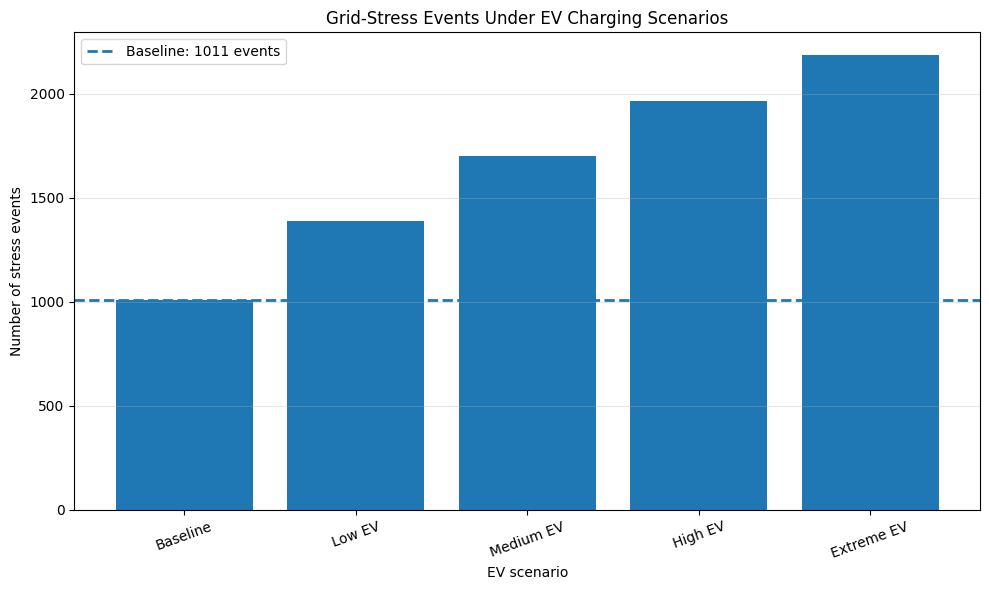

In [18]:
plt.figure(figsize=(10, 6))

plt.bar(
    ev_results["Scenario"],
    ev_results["Stress_Events"]
)

plt.axhline(
    baseline_stress_events,
    linestyle="--",
    linewidth=2,
    label=(
        f"Baseline: "
        f"{baseline_stress_events} events"
    )
)

plt.title(
    "Grid-Stress Events Under "
    "EV Charging Scenarios"
)
plt.xlabel("EV scenario")
plt.ylabel("Number of stress events")
plt.xticks(rotation=20)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "ev_stress_events_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

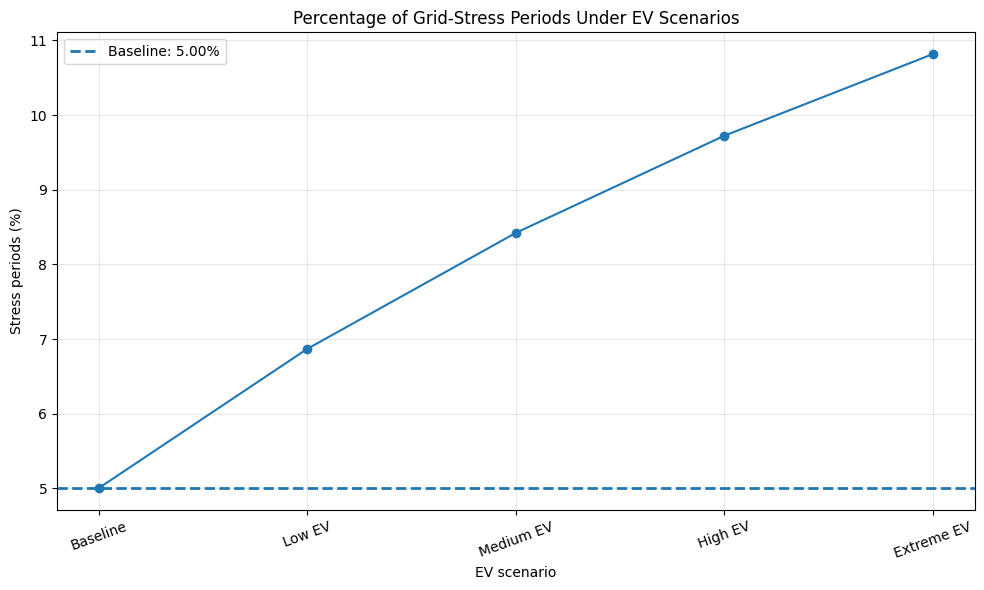

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    ev_results["Scenario"],
    ev_results["Stress_Percentage"],
    marker="o"
)

plt.axhline(
    baseline_stress_percentage,
    linestyle="--",
    linewidth=2,
    label=(
        f"Baseline: "
        f"{baseline_stress_percentage:.2f}%"
    )
)

plt.title(
    "Percentage of Grid-Stress Periods "
    "Under EV Scenarios"
)
plt.xlabel("EV scenario")
plt.ylabel("Stress periods (%)")
plt.xticks(rotation=20)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "ev_stress_percentage_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

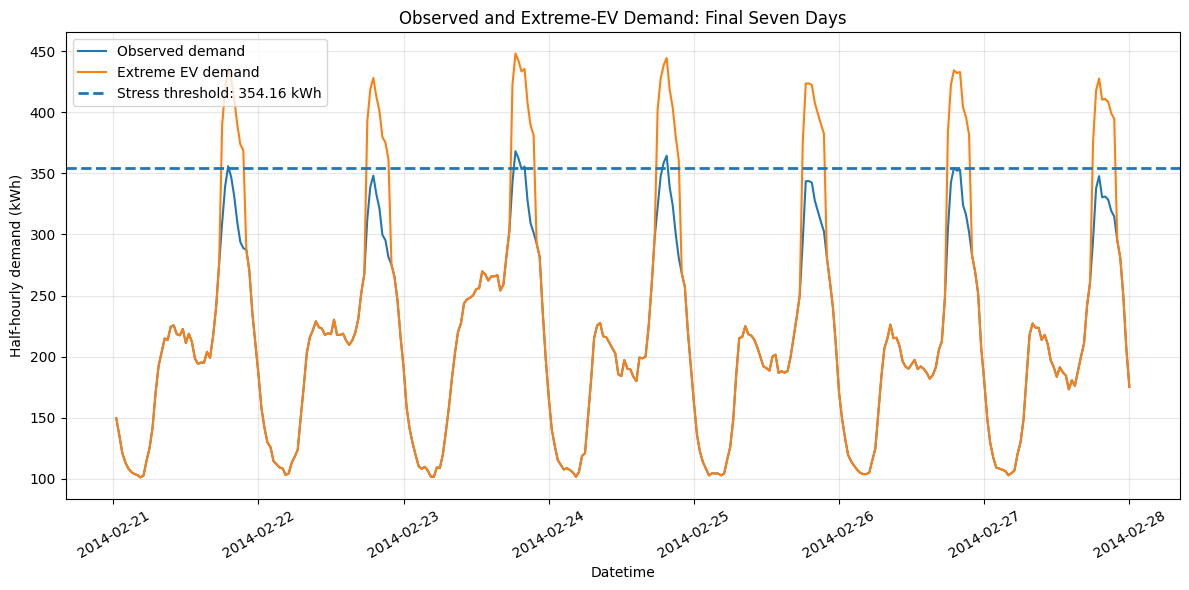

In [20]:
plot_sample = (
    scenario_datasets["Extreme EV"]
    .tail(48 * 7)
)

plt.figure(figsize=(12, 6))

plt.plot(
    plot_sample["datetime"],
    plot_sample["total_demand_kwh"],
    label="Observed demand"
)

plt.plot(
    plot_sample["datetime"],
    plot_sample["simulated_demand_kwh"],
    label="Extreme EV demand"
)

plt.axhline(
    stress_threshold,
    linestyle="--",
    linewidth=2,
    label=(
        f"Stress threshold: "
        f"{stress_threshold:.2f} kWh"
    )
)

plt.title(
    "Observed and Extreme-EV Demand: "
    "Final Seven Days"
)
plt.xlabel("Datetime")
plt.ylabel("Half-hourly demand (kWh)")
plt.xticks(rotation=30)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "extreme_ev_demand_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
print(
    "PHASE 9: EV DATA ANALYSIS "
    "AND SIMULATION COMPLETED"
)

print(
    "--------------------------------"
    "------------------"
)

print(
    f"Demand file: {demand_file}"
)

print(
    f"Stress threshold: "
    f"{stress_threshold:.4f} kWh"
)

print(
    f"Baseline stress events: "
    f"{baseline_stress_events}"
)

print(
    f"Baseline stress percentage: "
    f"{baseline_stress_percentage:.4f}%"
)

print()

display(ev_infrastructure_summary)
display(ev_results)

PHASE 9: EV DATA ANALYSIS AND SIMULATION COMPLETED
--------------------------------------------------
Demand file: ..\data\processed\model_ready_data.csv
Stress threshold: 354.1552 kWh
Baseline stress events: 1011
Baseline stress percentage: 5.0027%



,Charger_Category,Number_of_Chargers,Share_Percent
0,Standard,60039,50.419046
1,Standard Plus,31669,26.594726
2,Rapid,14451,12.135539
3,Ultra-Rapid,12921,10.850689


,Scenario,Additional_EV_Load_kWh,Stress_Events,Stress_Percentage,Increase_From_Baseline,Relative_Increase_Percent,Percentage_Point_Increase
0,Baseline,0,1011,5.002722,0,0.000000,0.000000
1,Low EV,20,1388,6.868227,377,37.289812,1.865505
2,Medium EV,40,1702,8.421990,691,68.348170,3.419269
3,High EV,60,1965,9.723391,954,94.362018,4.720669
4,Extreme EV,80,2186,10.816963,1175,116.221563,5.814241
